**Fraud Detection System**   

Internship - Oasis Infobyte (OIBSIP)    
Project 3, Proposal Level 2  
Author - Aniket Mishra

**Objective -**

The aim is to build a machine learning model that can accurately identify fraud credit card transactions. The project aims to analyze transaction data, understand the patterns of genuine and fraud transaction and use the Random Forest model to predict whether a new transaction is genuine or fraudulent.

**Understanding The Dataset -** 

The dataset contains credit card transactions made by cardholders. Each transaction is represented by several features and is classified as either normal or fraudulent.

In [1]:
# Import Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Looading Dataset

df = pd.read_csv("D:/Downloads/creditcard.csv.zip")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


**Observation -**  

The first five rows have been loaded. Each row represents a credit card transaction. 
The `Class` column is the `target variable`, where `0` indicates a `normal transaction` and `1` indicates a `fraudulent transaction`.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

**Observation -**    

The dataset contains numerical features with no datatype issues, therefore, no datatype conversion is required before analysis.

In [4]:
# Checking Missing Values

df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

**Observation -**  

No missing values were found in the dataset. Therefore, no data cleaning is required.

In [5]:
# Checking Duplicate Values

df.duplicated().sum()

np.int64(1081)

**Observations -**  

The dataset contains 1081 duplicate transactions.

**Observation -**  

In [6]:
# Removing Missing Values

df = df.drop_duplicates()

**Observation -** 

Duplicate transactions have been removed from the dataset.

In [7]:
# Statistical Summary

df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


**Observation -**

We can see a statistical summary of all numerical features in the dataset. The dataset contains mostly numerical features.  
The Time column shows that time elapsed for each transaction.  
The 25%, 50% (median), and 75% values describe how the data is distributed and help understand the spread of each feature.  
The standard deviation(50%) shows that how much the values vary from their average. 

In [8]:
# Fraud Distribution

df["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

**Observation -**  

The dataset is highly imbalanced. Most transactions are normal`Class = 0`, while only a very small number are fraudulent`Class = 1`.

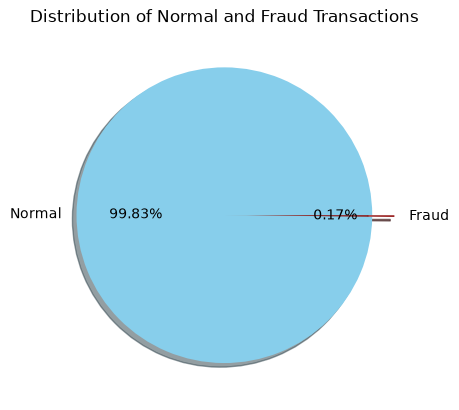

In [9]:
fraud_count = df["Class"].value_counts()
colors = ["skyblue", "darkred"]

plt.pie(fraud_count, labels = ["Normal","Fraud"], colors = colors, shadow = True, explode=(0, 0.15), autopct = "%.2f%%")
plt.title("Distribution of Normal and Fraud Transactions")
plt.show()

**Observation -**

This pie chart shows the distribution of normal and fraud transactions. `normal transactions` accounts for `99.83%`, whereas, `fraud transactions` accounts for only `0.17%` of all transactions.  
This shows that the dataset is highly imbalanced, as normal transactions greatly outnumber fraud ones.

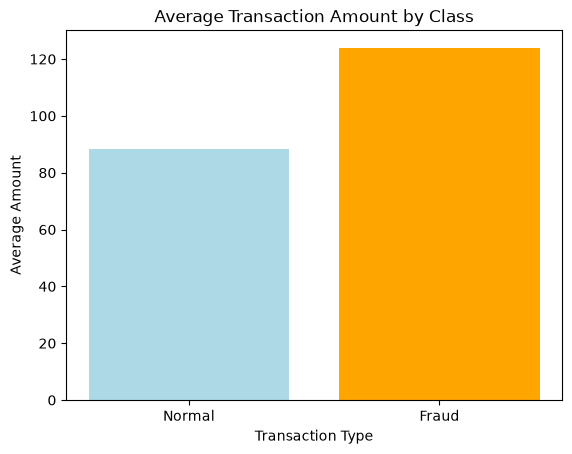

In [10]:
average_amount = df.groupby("Class")["Amount"].mean()
plt.bar(["Normal", "Fraud"], average_amount.values, color=["lightblue", "orange"])
plt.title("Average Transaction Amount by Class")

plt.xlabel("Transaction Type")
plt.ylabel("Average Amount")
plt.show()

**Observation -**

This graph compares the average transaction amount for normal and fraud transactions. `X-axis` represents the `type of transaction`, normal or fraud, whereas, `Y-axis` represents the `average transaction amount`.    
The `Normal transactions` have an average amount of approx `90`, whereas, `Fraud transactions` have an average amount of approx `120`.   
This suggests that fraud transactions may involve larger amounts of money, although not every high value transaction is necessarily fraudulent.

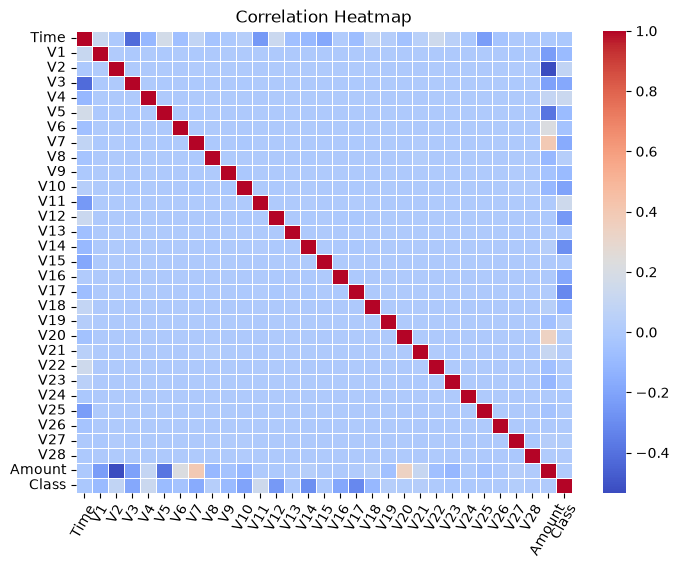

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), cmap = "coolwarm", linewidths = 0.5)

plt.xticks(rotation = 60)
plt.title("Correlation Heatmap")
plt.show()

**Observation -**  

The correlation heatmap shows the relationship between all numerical features in the dataset.   
Most cells are light blue or white, indicating that most features have weak or no correlation with one another. The diagonal red line shows a perfect correlation because every feature is compared with itself.  
Only a few features show moderate positive or negative relationships.

In [12]:
# Feature and Target Variable

x = df.drop("Class", axis = 1)
y = df["Class"]

**Observation -**  

The dataset has been divided into `feature(x)` and `target variable(y)`. The feature variables contain all transaction details, whereas, the target variable(Class) tells whether a transaction is normal(0) or fraud(1).

In [13]:
# Splitting the dataset

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

**Observation -**  

The dataset is divided into training and testing sets. The `training data(80%)` is used to train the model, while the `testing data(20%)` is used to evaluate it's performance on unseen transactions.

In [14]:
# Training the Model

model = RandomForestClassifier(n_estimators = 50, random_state = 42, n_jobs = -1)
model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total 

**Observation -**

`Random Forest model` has been trained using the training data. The model learns patterns that help distinguish between genuine and fraud transactions.

In [15]:
# Prediction

y_pred = model.predict(x_test)

**Observation -**

The trained model has predicted the class of each transaction in the dataset.

In [16]:
# Accuracy Score

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.9995065731505305


**Observation -**

The Random Forest model achieved an accuracy of 99%. This shows that the model performs very well.

In [17]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[56654     2]
 [   26    64]]


**Observation -**

It compares the model's predictions with the actual transaction classes. 
Most transactions be it genuine or fraud were correctly identified, only a small number of transactions were misclassified.

In [18]:
# Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.97      0.71      0.82        90

    accuracy                           1.00     56746
   macro avg       0.98      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746



**Observation -**

It provides detailed performance metrics such as Precision, Recall and F1 score.   
Random Forest model performed exceptionally well in identifying normal transactions as well as detecting fraudulent transactions, despite the dataset being highly imbalanced.

In [19]:
# Transaction Example 1

new_transaction = x.iloc[[0]]
prediction = model.predict(new_transaction)

if prediction[0] == 0:
    print("Prediction: Genuine Transaction")
else:
    print("Prediction: Fraud Transaction")

Prediction: Genuine Transaction


In [20]:
# Transaction Example 2

new_transaction = x[y == 1].iloc[[0]]
prediction = model.predict(new_transaction)

if prediction[0] == 0:
    print("Prediction: Genuine Transaction")
else:
    print("Prediction: Fraud Transaction")

Prediction: Fraud Transaction


**Observation -** 

The newly trained Random Forest model was tested using two transactions from the dataset.  
In the first example, the model correctly predicted the transaction as Genuine, whereas, in the second example, the model correctly predicted the transaction as Fraudulent.  
This shows that the model has successfully learned the patterns of both type of transactions.

**Key Insights -**
    
1. The dataset contains a very large number of transactions, making it suitable for machine learning analysis.
2. No missing values were found, so the dataset was already clean.
3. Duplicate transactions were identified and removed to improve data quality.
4. The dataset was highly imbalanced, with far more normal transactions than fraudulent ones.
5. The Random Forest model successfully learned the patterns in the data and achieved very high prediction accuracy.
6. The confusion matrix and classification report showed that the model correctly classified most normal and fraudulent transactions.

**Conclusion -**

1. The project successfully built a fraud detection system using the Random Forest Classifier model.  
2. After cleaning and analyzing the dataset, the model was trained and tested.  
3. It achieved very high accuracy approx 99.99% and demonstrated strong performance in distinguishing between normal and fraud transactions.  
4. This shows that machine learning can effectively identify suspicious financial transactions and support reak time fraud detection systems.